In [2]:
import pandas as pd
import numpy as np
import matplotlib as mat
import seaborn as sns

In [3]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [4]:
from pathlib import Path
DATA_DIR=Path("C:/Project_Folder_ML26/Notebook/data/raw")
DATA_DIR.exists()

True

In [5]:
customers = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_customers_dataset.csv")
geolocation = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_geolocation_dataset.csv")
order_items = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_order_reviews_dataset.csv")
orders = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_orders_dataset.csv")
products = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("C:/Project_Folder_ML26/Notebook/data/raw/product_category_name_translation.csv")

In [6]:
tables = {
"customers": customers,
"geolocation": geolocation,
"order_items": order_items,
"payments": payments,
"reviews": reviews,
"orders": orders,
"products": products,
"sellers": sellers,
"category_translation": category_translation}

In [7]:
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 99441 rows, 5 columns
geolocation: 1000163 rows, 5 columns
order_items: 112650 rows, 7 columns
payments: 103886 rows, 5 columns
reviews: 99224 rows, 7 columns
orders: 99441 rows, 8 columns
products: 32951 rows, 9 columns
sellers: 3095 rows, 4 columns
category_translation: 71 rows, 2 columns


In [8]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [9]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [10]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [11]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [12]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [13]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [14]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [15]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [16]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [18]:
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 99441 rows, 5 columns
geolocation: 1000163 rows, 5 columns
order_items: 112650 rows, 7 columns
payments: 103886 rows, 5 columns
reviews: 99224 rows, 7 columns
orders: 99441 rows, 8 columns
products: 32951 rows, 9 columns
sellers: 3095 rows, 4 columns
category_translation: 71 rows, 2 columns


In [20]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [21]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)
    print(df.info())


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB
None

GEOLOCATION
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str

In [24]:
def summarize_table(name, df):
     return {
         "table_name": name,
         "rows": df.shape[0],
         "columns": df.shape[1],
         "missing_values": df.isnull().sum().sum(),
         "duplicate_rows": df.duplicated().sum()
         }
summary= pd. DataFrame([summarize_table(name, df) for name, df in tables.items()])

In [25]:
summary

,table_name,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [26]:
summary.to_csv("C:/Project_Folder_ML26/Notebook/reports/lab01_dataset_summary.csv", index=False)

In [35]:
def missing_value_summary(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    result = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })

    return result[result["missing_count"] > 0].sort_values(
        by="missing_percent",
        ascending=False
    )

missing_value_summary(orders)

,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


In [39]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(f"Missing Values in {name}")
    print("=" * 80)
    display(missing_value_summary(df))


Missing Values in customers


,missing_count,missing_percent



Missing Values in geolocation


,missing_count,missing_percent



Missing Values in order_items


...

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



Missing Values in sellers


,missing_count,missing_percent



Missing Values in category_translation


,missing_count,missing_percent


In [40]:
for name, df in tables.items():
     duplicate_count = df.duplicated().sum()
     print(f"{name}: {duplicate_count} duplicate rows")

customers: 0 duplicate rows
geolocation: 261831 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
orders: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
category_translation: 0 duplicate rows


In [43]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

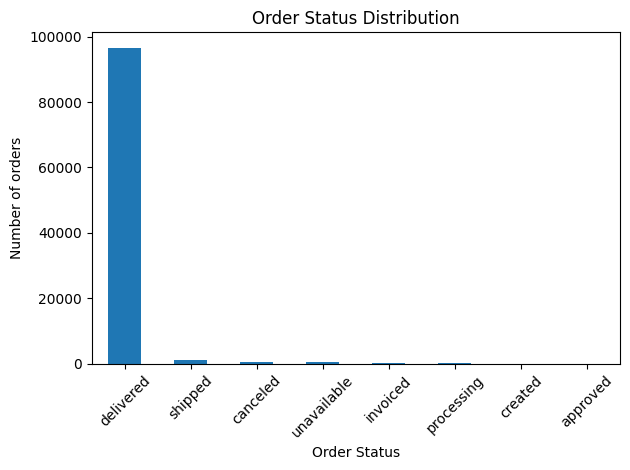

In [46]:
import matplotlib.pyplot as plt
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("C:/Project_Folder_ML26/Notebook/figures/order_status_distri.png")
plt.show()

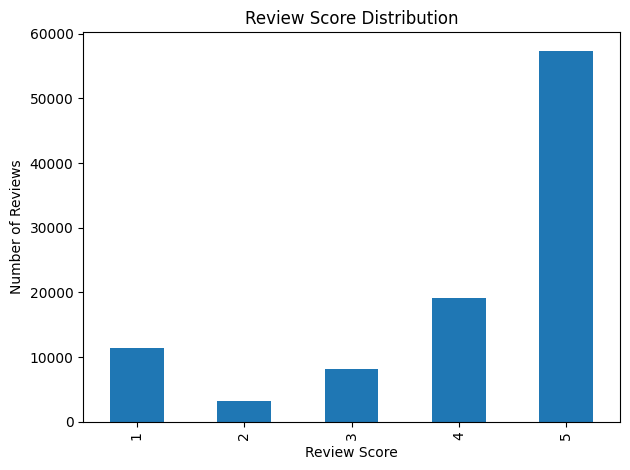

In [47]:
reviews["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("C:/Project_Folder_ML26/Notebook/figures/review.png")
plt.show()

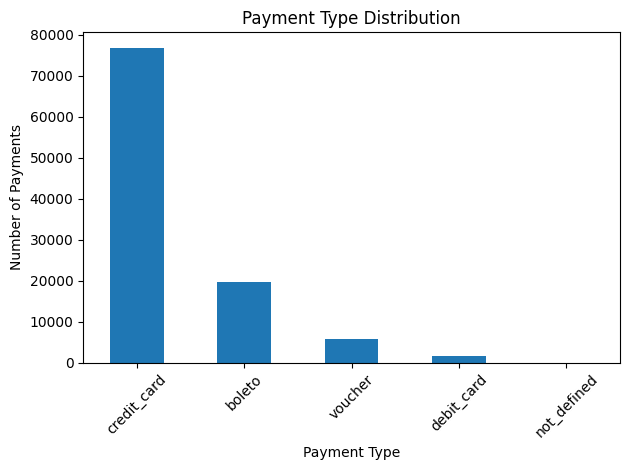

In [48]:
payments["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("C:/Project_Folder_ML26/Notebook/figures/payment.png")
plt.show()

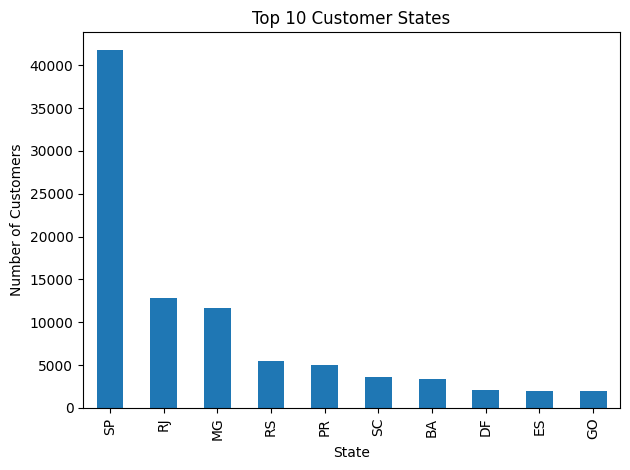

In [49]:
customers["customer_state"].value_counts().head (10).plot(kind="bar")
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("C:/Project_Folder_ML26/Notebook/figures/customer.png")
plt.show()

In [51]:
#Initial Business Questions
#How many unique customers are present?
customers ["customer_unique_id"].nunique()

96096

In [52]:
#How many orders are present?
orders ["order_id"].nunique()

99441

In [53]:
#What are the most common order statuses?
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [54]:
#What are the most common payment methods?
payments ["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [55]:
#What is the average review score?
reviews["review_score"].mean()

np.float64(4.08642062404257)

In [4]:
import os
import pandas as pd

In [6]:
data_path = r"C:\Project_Folder_ML26\Notebook\data\raw"
data_dict = []
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        try:
            df = pd.read_csv(file_path, nrows=5)
            for col in df.columns:
                entry = {
                    "File_Name": file,
                    "Column_Name": col,
                    "Data_Type": str(df[col].dtype),
                    "Sample_Value": df[col].iloc[0] if not df[col].empty else None
                }
                data_dict.append(entry)
        except Exception as e:
            print(f"Error reading {file}: {e}")

data_dictionary = pd.DataFrame(data_dict)
output_path = os.path.join(data_path, "Olist_Data_Dictionary.csv")
data_dictionary.to_csv(output_path, index=False)

print(f"Data dictionary created and saved at: {output_path}")

Data dictionary created and saved at: C:\Project_Folder_ML26\Notebook\data\raw\Olist_Data_Dictionary.csv
